In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, roc_auc_score, f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Imports OK')

✅ Imports OK


In [2]:
df = pd.read_csv('../data/students.csv')
print(f'Shape: {df.shape}')
print(f'At-risk ratio: {df["at_risk"].mean():.2%}')
df.head()

Shape: (1200, 13)
At-risk ratio: 18.00%


,student_id,department,semester,attendance_pct,internal_marks,assignment_submission_rate,prev_semester_cgpa,lab_attendance_pct,quiz_avg_score,library_visits_per_month,extracurricular_participation,active_backlogs,at_risk
0,STU40953,CIVIL,7,86.48,74.98,83.60,6.77,86.42,93.57,4,1,0,0
1,STU73857,CSE,5,84.56,48.64,86.09,7.57,86.00,54.96,7,0,1,0
2,STU20155,MECH,8,57.37,42.49,25.62,5.87,48.65,54.57,1,1,2,1
3,STU94085,CSE,5,78.89,76.89,68.54,7.11,81.23,77.35,6,1,0,0
4,STU58434,ECE,6,45.41,36.35,45.01,5.36,39.99,36.79,1,1,2,1


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Data Types ===
student_id                        object
department                        object
semester                           int64
attendance_pct                   float64
internal_marks                   float64
assignment_submission_rate       float64
prev_semester_cgpa               float64
lab_attendance_pct               float64
quiz_avg_score                   float64
library_visits_per_month           int64
extracurricular_participation      int64
active_backlogs                    int64
at_risk                            int64
dtype: object

=== Missing Values ===
student_id                       0
department                       0
semester                         0
attendance_pct                   0
internal_marks                   0
assignment_submission_rate       0
prev_semester_cgpa               0
lab_attendance_pct               0
quiz_avg_score                   0
library_visits_per_month         0
extracurricular_participation    0
active_backlogs          

,semester,attendance_pct,internal_marks,assignment_submission_rate,prev_semester_cgpa,lab_attendance_pct,quiz_avg_score,library_visits_per_month,extracurricular_participation,active_backlogs,at_risk
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,4.47,77.16,63.31,74.92,7.32,78.73,58.87,3.46,0.58,0.71,0.18
std,2.26,14.17,15.56,18.38,1.39,14.98,16.67,2.18,0.49,1.16,0.38
min,1.00,17.87,8.79,0.00,2.59,18.31,0.54,0.00,0.00,0.00,0.00
25%,3.00,70.39,55.64,66.75,6.70,71.17,49.45,2.00,0.00,0.00,0.00
50%,4.00,79.47,66.06,78.62,7.55,81.64,60.49,3.00,1.00,0.00,0.00
75%,6.00,86.82,73.88,87.44,8.28,89.01,70.48,5.00,1.00,1.00,0.00
max,8.00,100.00,98.87,100.00,10.00,100.00,100.00,11.00,1.00,7.00,1.00


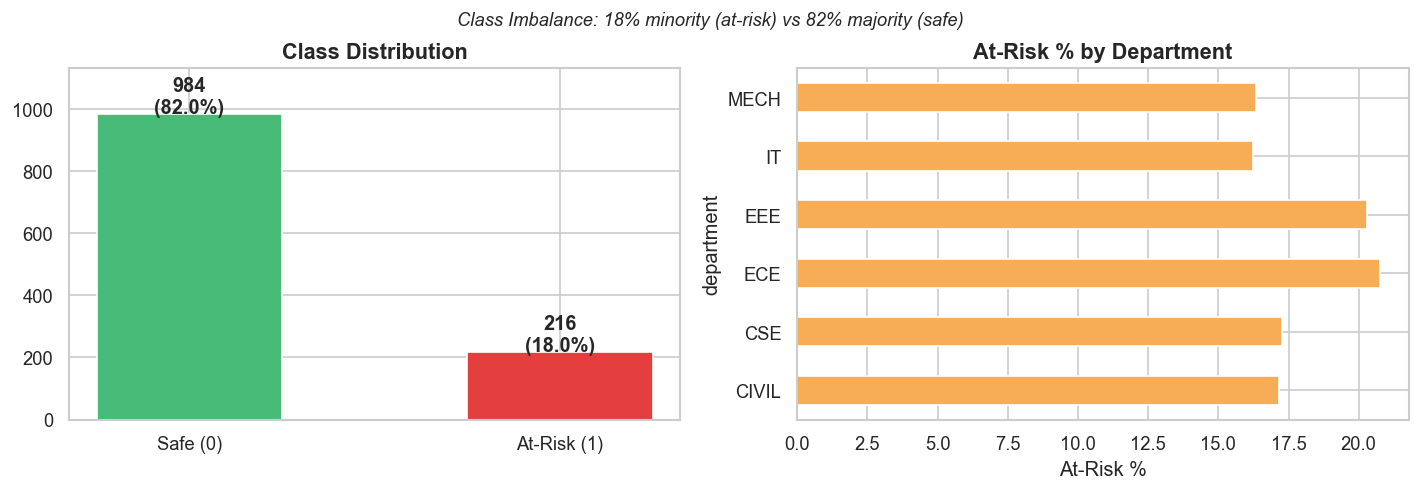

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['at_risk'].value_counts()
axes[0].bar(['Safe (0)', 'At-Risk (1)'], counts.values, color=['#48bb78', '#e53e3e'], width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=13)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df):.1%})', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.15)

# Department breakdown
dept_risk = df.groupby('department')['at_risk'].agg(['sum','count'])
dept_risk['pct'] = dept_risk['sum'] / dept_risk['count'] * 100
dept_risk['pct'].plot(kind='barh', ax=axes[1], color='#f6ad55')
axes[1].set_title('At-Risk % by Department', fontweight='bold', fontsize=13)
axes[1].set_xlabel('At-Risk %')

plt.tight_layout()
plt.suptitle('Class Imbalance: 18% minority (at-risk) vs 82% majority (safe)', 
             y=1.02, fontsize=11, style='italic')
plt.show()

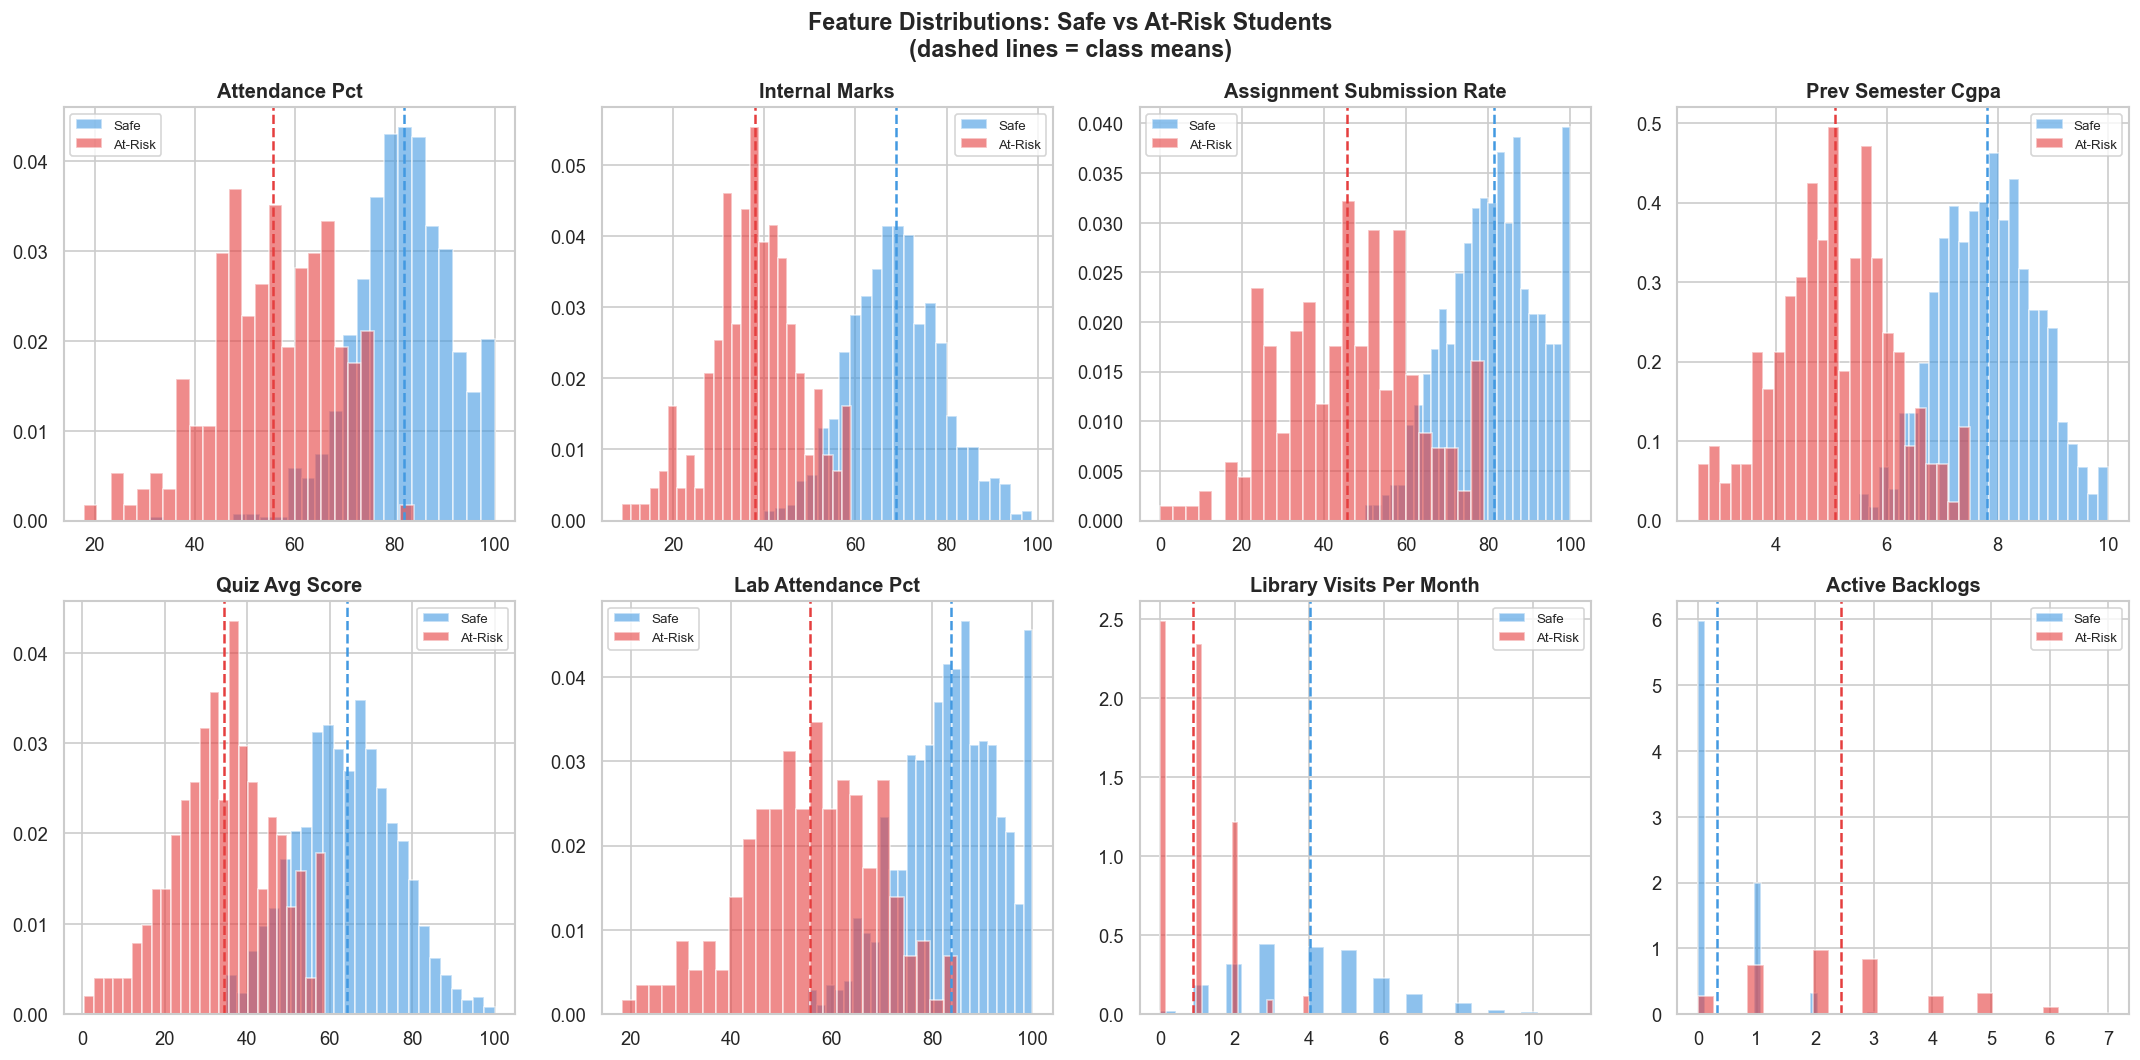

In [5]:
NUMERIC_FEATURES = [
    'attendance_pct', 'internal_marks', 'assignment_submission_rate',
    'prev_semester_cgpa', 'quiz_avg_score', 'lab_attendance_pct',
    'library_visits_per_month', 'active_backlogs'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
colors = {0: '#4299e1', 1: '#e53e3e'}
labels = {0: 'Safe', 1: 'At-Risk'}

for ax, feat in zip(axes.flat, NUMERIC_FEATURES):
    for cls in [0, 1]:
        data = df[df['at_risk'] == cls][feat]
        ax.hist(data, bins=25, alpha=0.6, color=colors[cls], 
                label=labels[cls], density=True)
        ax.axvline(data.mean(), color=colors[cls], linestyle='--', linewidth=1.5)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Safe vs At-Risk Students\n(dashed lines = class means)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

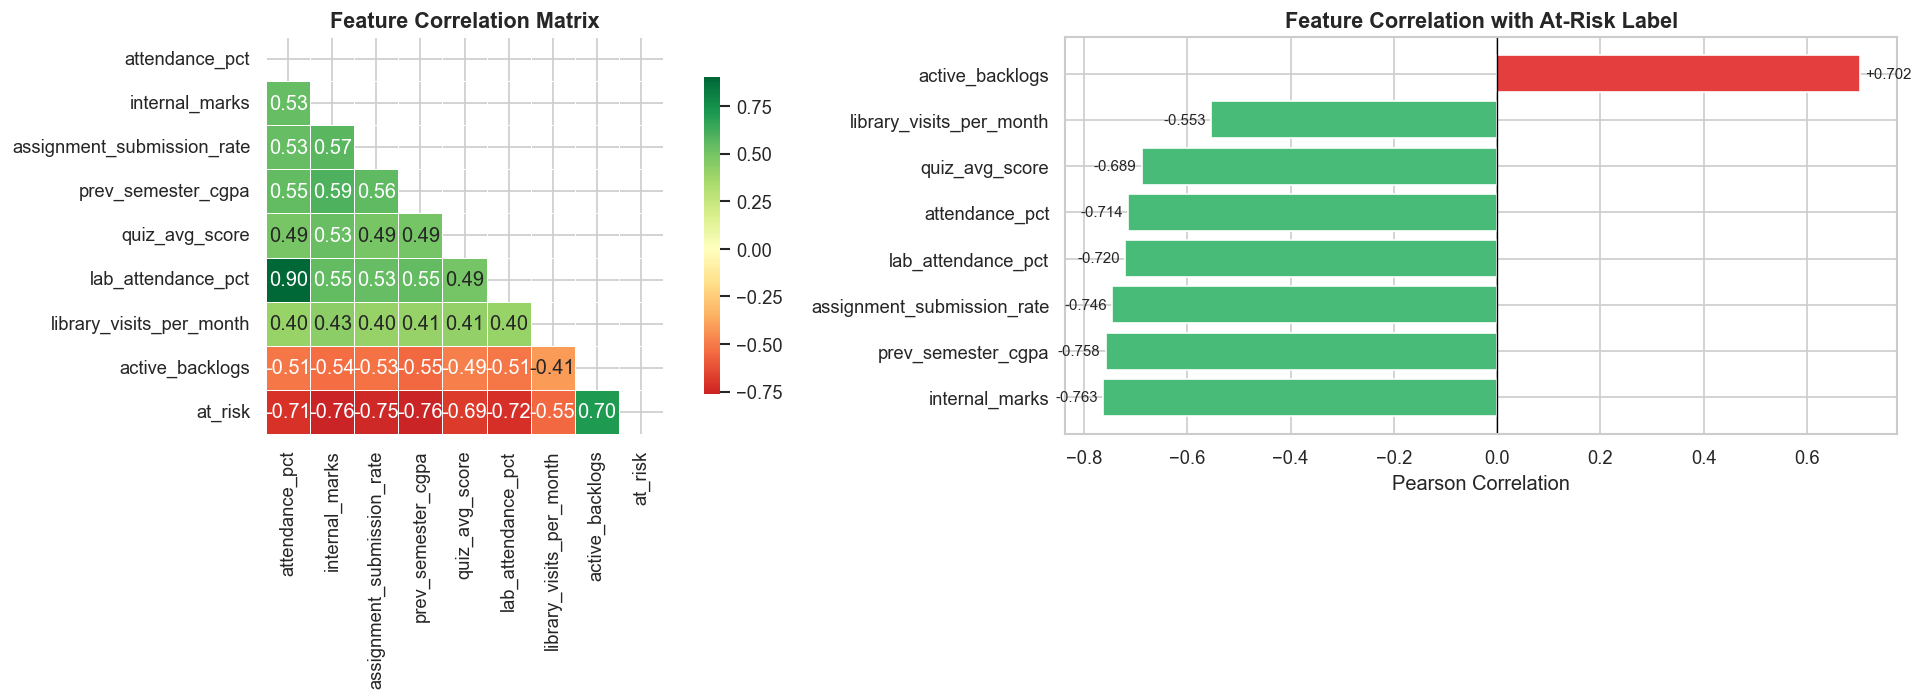


Top positive correlators with at-risk (increase risk):
active_backlogs    0.702201
Name: at_risk, dtype: float64

Top negative correlators (protective factors):
internal_marks               -0.763260
prev_semester_cgpa           -0.758171
assignment_submission_rate   -0.746046
lab_attendance_pct           -0.720446
attendance_pct               -0.714255
quiz_avg_score               -0.688846
library_visits_per_month     -0.553306
Name: at_risk, dtype: float64


In [6]:
corr_cols = NUMERIC_FEATURES + ['at_risk']
corr = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)

# Correlation with target only
target_corr = corr['at_risk'].drop('at_risk').sort_values()
colors_bar = ['#48bb78' if v < 0 else '#e53e3e' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with At-Risk Label', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Pearson Correlation')
for i, (feat, val) in enumerate(target_corr.items()):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i, f'{val:+.3f}', 
                 va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('\nTop positive correlators with at-risk (increase risk):')
print(target_corr[target_corr > 0].sort_values(ascending=False))
print('\nTop negative correlators (protective factors):')
print(target_corr[target_corr < 0].sort_values())

In [26]:
import json
import joblib
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# Load files
pipeline = joblib.load('../models/risk_pipeline.pkl')
le_dept = joblib.load('../models/le_dept.pkl')

with open('../models/metrics.json', 'r') as f:
    metrics = json.load(f)

# Copy dataframe
df_enc = df.copy()

# Encode department safely
df_enc['department'] = df_enc['department'].astype(str)
df_enc['dept_enc'] = le_dept.transform(df_enc['department'])

# Features / target
X = df_enc[metrics['feature_names']]
y = df_enc['at_risk']

# Cross-validation probabilities
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_probs = cross_val_predict(
    estimator=pipeline,
    X=X,
    y=y,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# Threshold predictions
threshold = metrics.get('best_threshold', 0.5)
cv_preds = (cv_probs >= threshold).astype(int)

# Results
print("=== Cross-Validated Metrics ===")
print(classification_report(y, cv_preds, target_names=['Safe', 'At-Risk']))
print("AUC-ROC :", round(roc_auc_score(y, cv_probs), 4))
print("F1 Score:", round(f1_score(y, cv_preds), 4))

=== Cross-Validated Metrics ===
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       984
     At-Risk       1.00      1.00      1.00       216

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200

AUC-ROC : 1.0
F1 Score: 0.9977


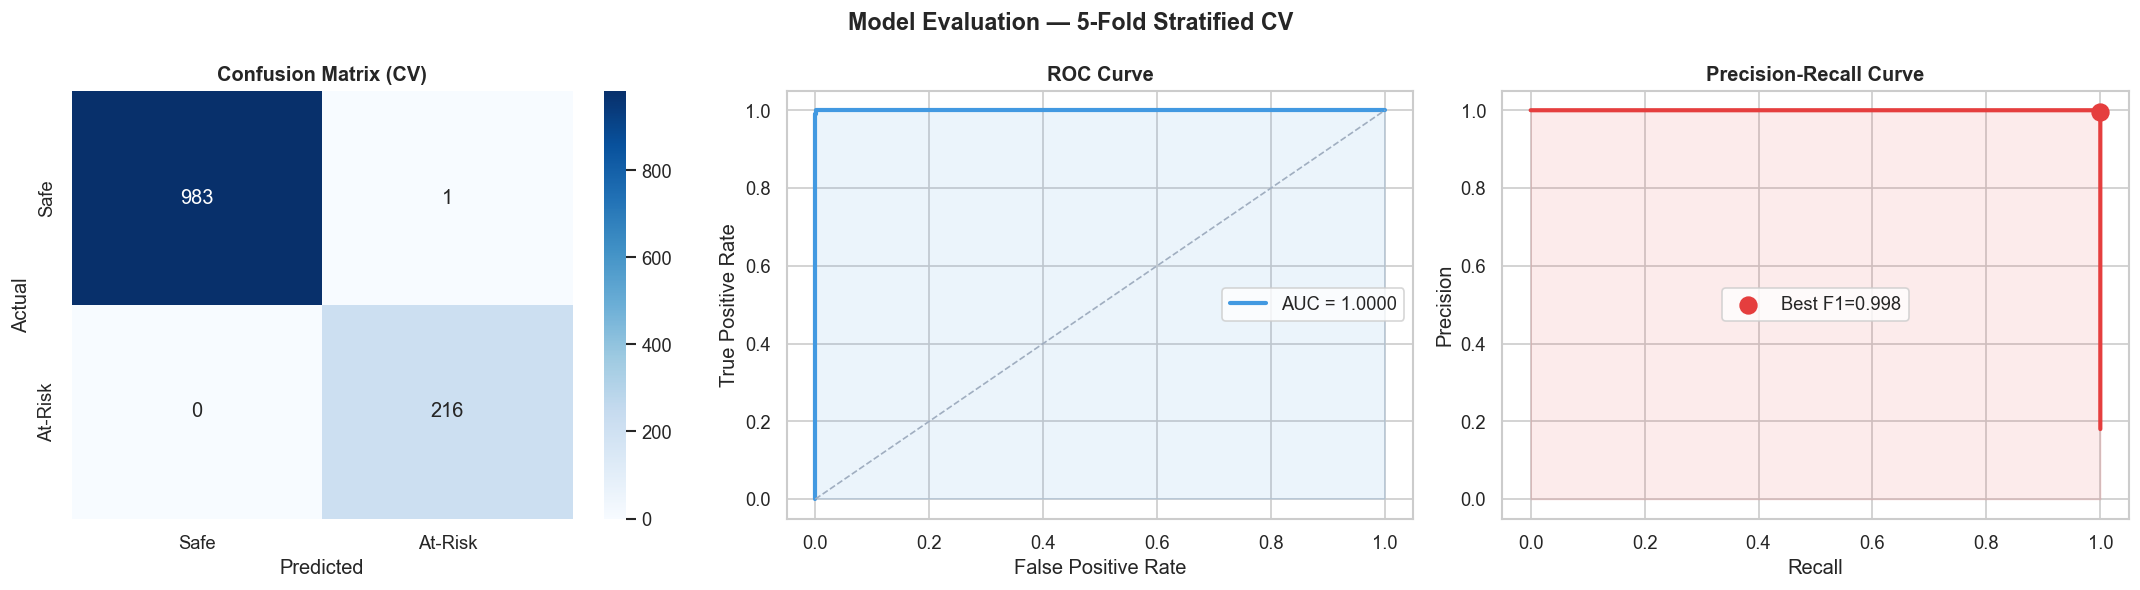

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y, cv_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Safe','At-Risk'], yticklabels=['Safe','At-Risk'])
axes[0].set_title('Confusion Matrix (CV)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y, cv_probs)
auc = roc_auc_score(y, cv_probs)
axes[1].plot(fpr, tpr, color='#4299e1', lw=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'--', color='#a0aec0', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#4299e1')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 3. Precision-Recall Curve
prec, rec, thresholds_pr = precision_recall_curve(y, cv_probs)
f1_scores_pr = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1_scores_pr)
axes[2].plot(rec, prec, color='#e53e3e', lw=2.5)
axes[2].scatter(rec[best_idx], prec[best_idx], s=100, color='#e53e3e', 
                zorder=5, label=f'Best F1={f1_scores_pr[best_idx]:.3f}')
axes[2].fill_between(rec, prec, alpha=0.1, color='#e53e3e')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.suptitle('Model Evaluation — 5-Fold Stratified CV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

SHAP values shape: (1200, 11)


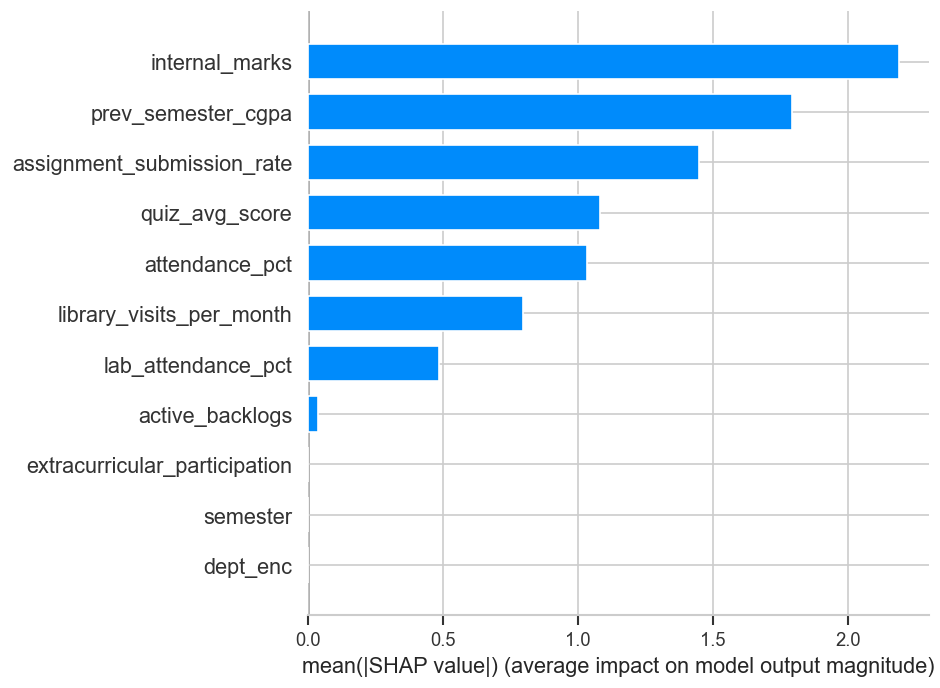

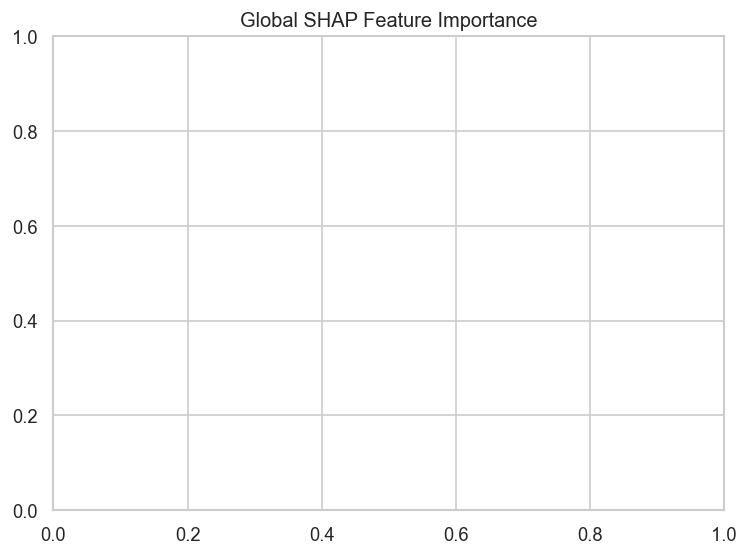

In [28]:
explainer = joblib.load('../models/shap_explainer.pkl')
shap_values = explainer.shap_values(X)

print('SHAP values shape:', shap_values.shape)

# Global bar plot
shap.summary_plot(shap_values, X, plot_type='bar', show=True)
plt.title('Global SHAP Feature Importance')
plt.tight_layout()
plt.show()

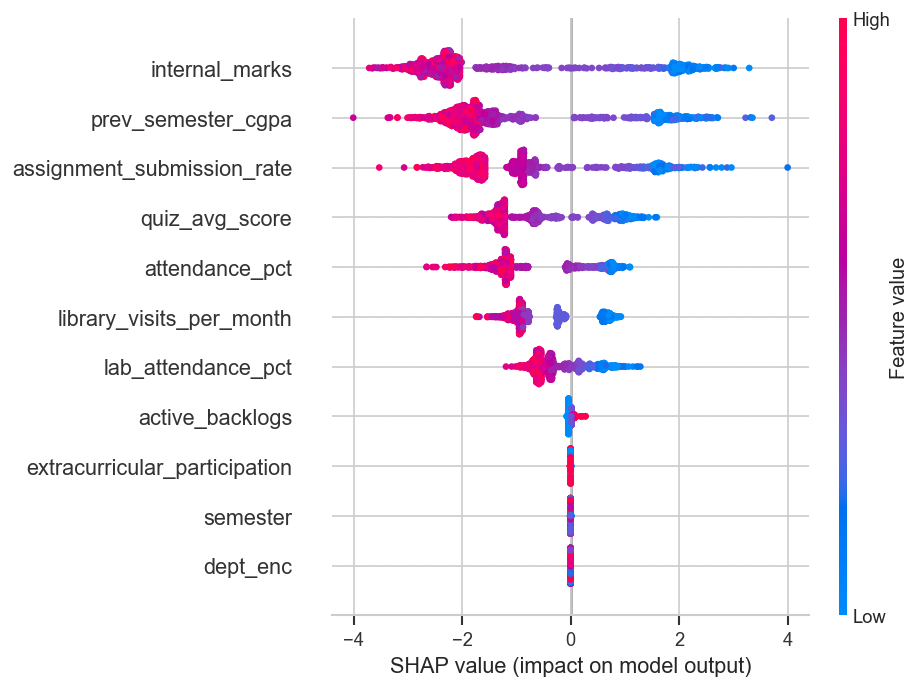

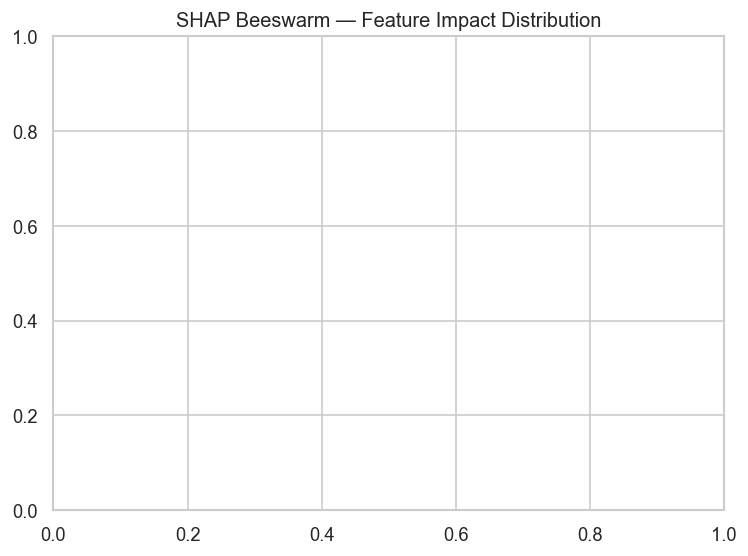

In [29]:
# Beeswarm (full impact distribution)
shap.summary_plot(shap_values, X, show=True)
plt.title('SHAP Beeswarm — Feature Impact Distribution')
plt.tight_layout()
plt.show()

Highest-risk student index: 4
Student ID : STU58434
Department : ECE
Risk prob  : 99.99%


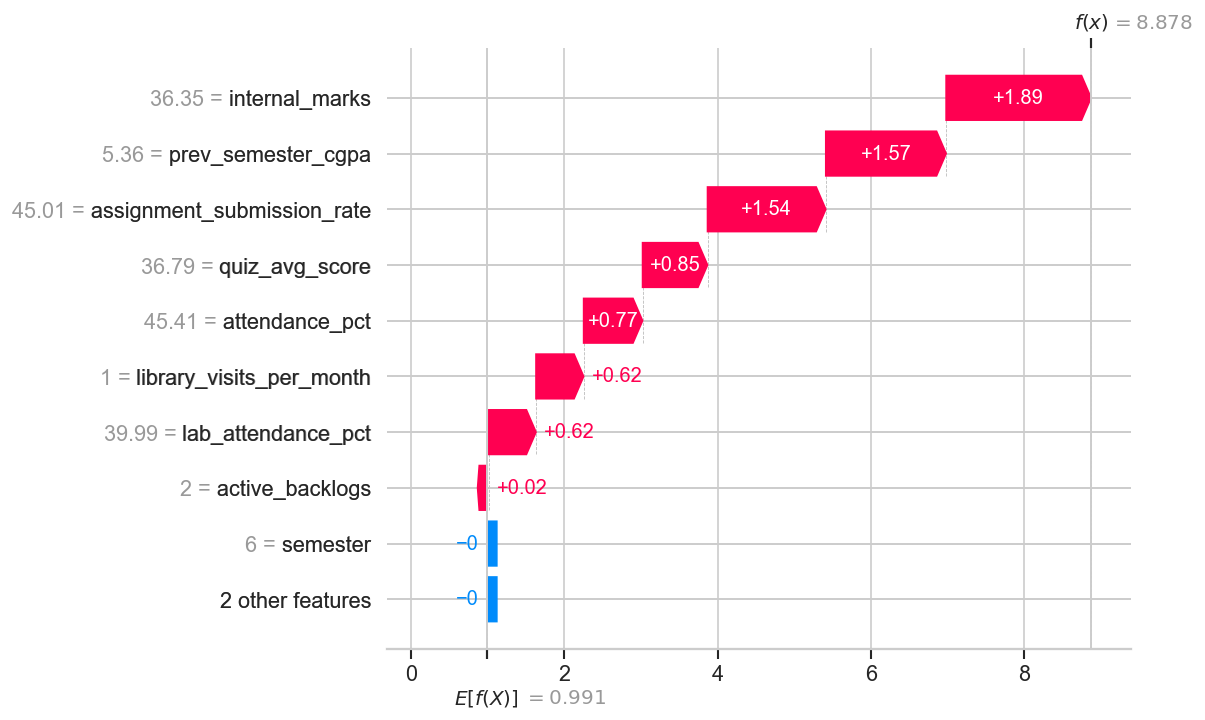

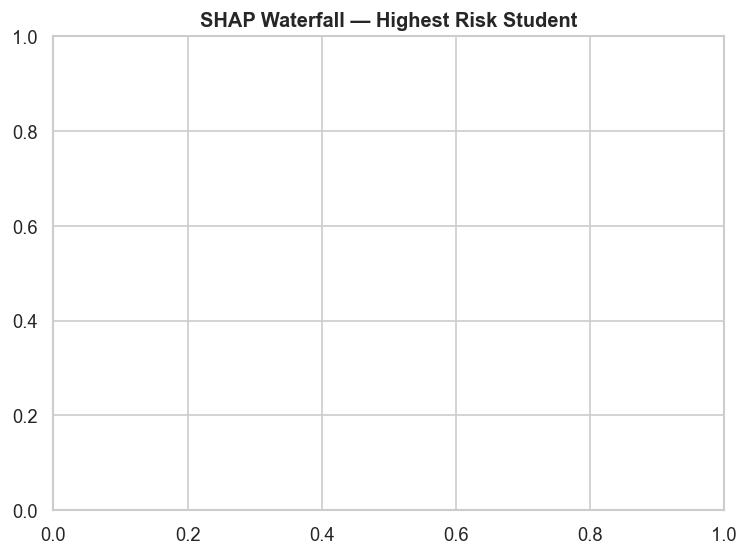

In [30]:
# --- Per-student waterfall for the highest-risk student ---
proba = pipeline.predict_proba(X)[:, 1]
highest_risk_idx = np.argmax(proba)

print(f'Highest-risk student index: {highest_risk_idx}')
print(f'Student ID : {df.iloc[highest_risk_idx]["student_id"]}')
print(f'Department : {df.iloc[highest_risk_idx]["department"]}')
print(f'Risk prob  : {proba[highest_risk_idx]:.2%}')

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X.iloc[highest_risk_idx].values,
        feature_names=metrics['feature_names']
    )
)
plt.title(f'SHAP Waterfall — Highest Risk Student', fontweight='bold')
plt.tight_layout()
plt.show()

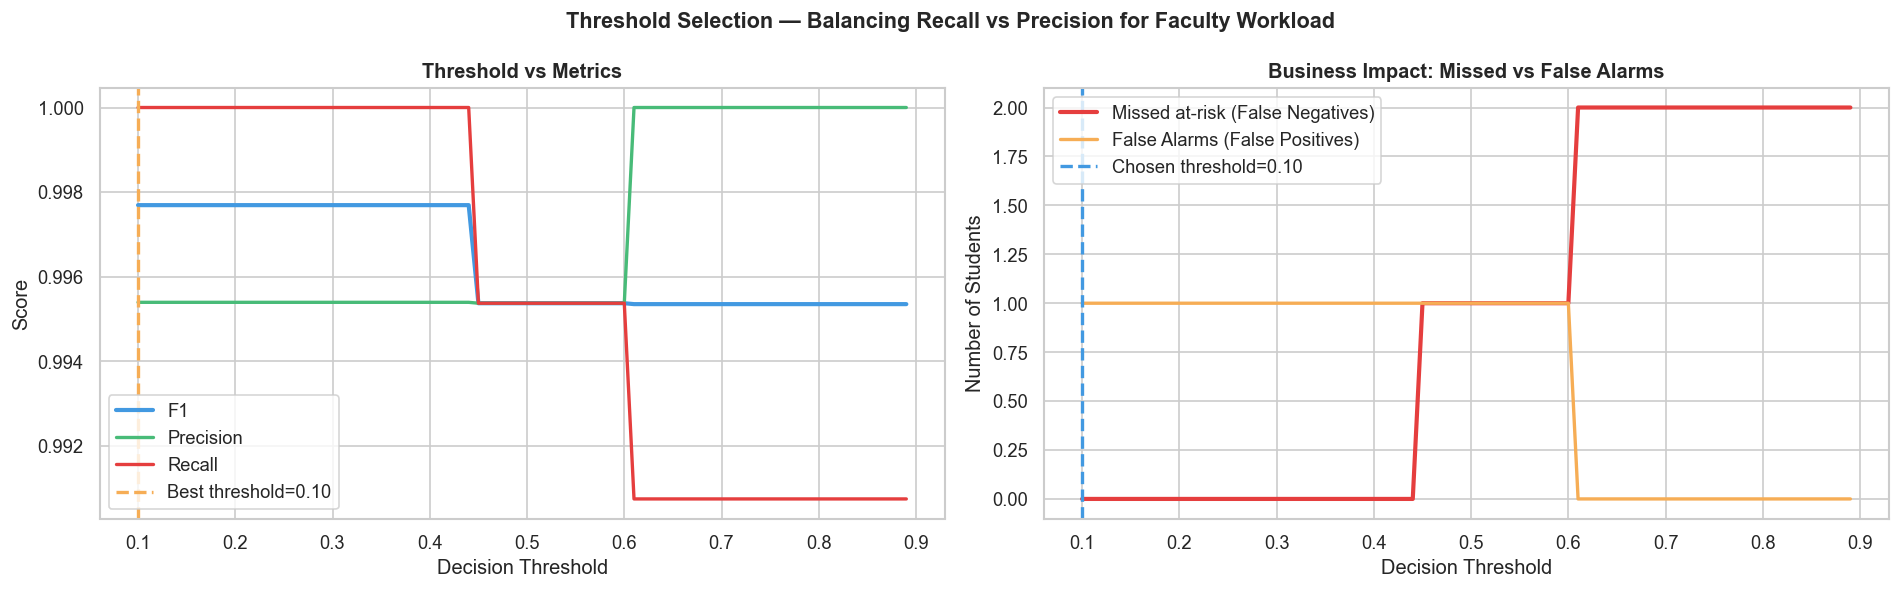


At threshold=0.10:
  F1=0.9977 | Precision=0.9954 | Recall=1.0000
  Missed at-risk students : 0
  Unnecessary alerts sent : 1


In [31]:
thresholds = np.arange(0.10, 0.90, 0.01)
f1s, precisions, recalls = [], [], []

for t in thresholds:
    preds = (cv_probs >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    f1s.append(f1_score(y, preds, zero_division=0))
    precisions.append(precision_score(y, preds, zero_division=0))
    recalls.append(recall_score(y, preds, zero_division=0))

best_t_idx = np.argmax(f1s)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds, f1s, label='F1', color='#4299e1', lw=2.5)
axes[0].plot(thresholds, precisions, label='Precision', color='#48bb78', lw=2)
axes[0].plot(thresholds, recalls, label='Recall', color='#e53e3e', lw=2)
axes[0].axvline(thresholds[best_t_idx], color='#f6ad55', linestyle='--', lw=2,
               label=f'Best threshold={thresholds[best_t_idx]:.2f}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold vs Metrics', fontweight='bold')
axes[0].legend()

# Business impact: missed at-risk students vs false alarms
false_alarms = [(cv_probs >= t).astype(int).sum() - (cv_probs[y==1] >= t).sum() for t in thresholds]
missed       = [(y == 1).sum() - (cv_probs[y==1] >= t).sum() for t in thresholds]

axes[1].plot(thresholds, missed, label='Missed at-risk (False Negatives)', color='#e53e3e', lw=2.5)
axes[1].plot(thresholds, false_alarms, label='False Alarms (False Positives)', color='#f6ad55', lw=2)
axes[1].axvline(thresholds[best_t_idx], color='#4299e1', linestyle='--', lw=2,
               label=f'Chosen threshold={thresholds[best_t_idx]:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Number of Students')
axes[1].set_title('Business Impact: Missed vs False Alarms', fontweight='bold')
axes[1].legend()

plt.suptitle('Threshold Selection — Balancing Recall vs Precision for Faculty Workload',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nAt threshold={thresholds[best_t_idx]:.2f}:')
print(f'  F1={f1s[best_t_idx]:.4f} | Precision={precisions[best_t_idx]:.4f} | Recall={recalls[best_t_idx]:.4f}')
print(f'  Missed at-risk students : {missed[best_t_idx]}')
print(f'  Unnecessary alerts sent : {false_alarms[best_t_idx]}')

Risk Level Distribution:
risk_level
Low         984
Critical    216
Name: count, dtype: int64


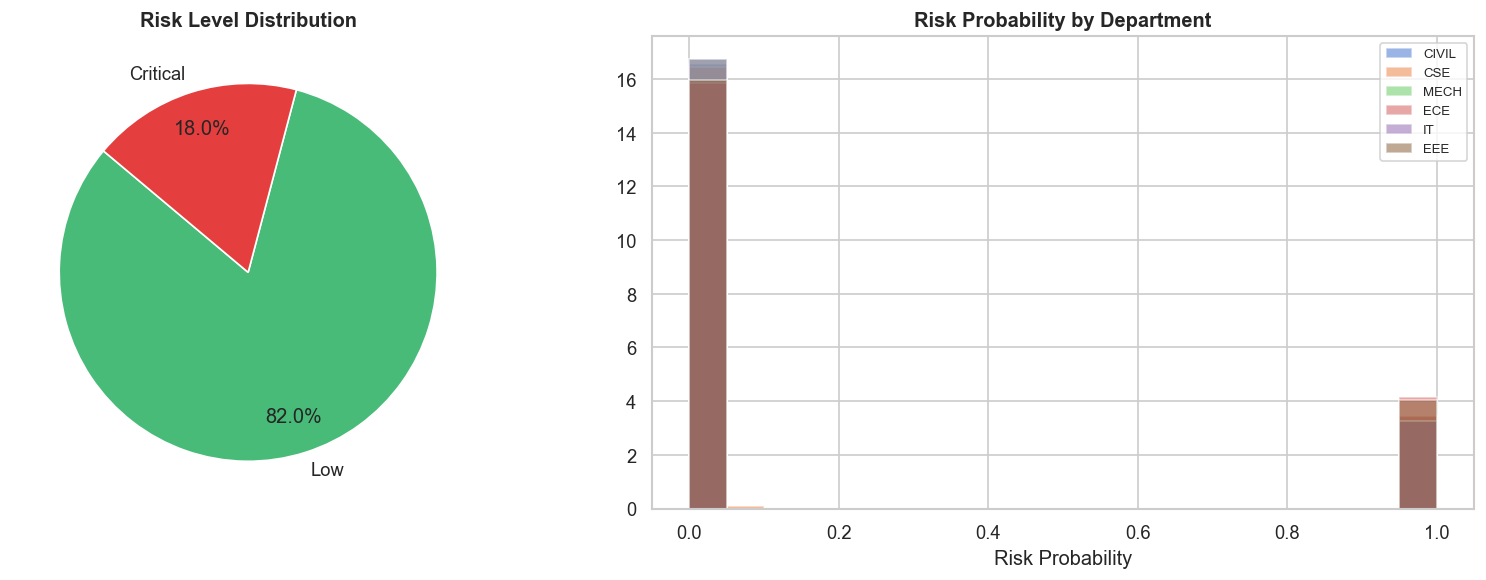


Top 10 Highest Risk Students:


,student_id,department,semester,attendance_pct,internal_marks,risk_probability,risk_level
1123,STU67711,EEE,6,63.89,32.87,0.9999,Critical
848,STU80678,CSE,4,59.61,37.67,0.9999,Critical
405,STU91560,IT,3,59.97,36.15,0.9999,Critical
1039,STU92213,CIVIL,4,45.44,39.09,0.9999,Critical
103,STU97062,EEE,4,59.90,36.14,0.9999,Critical
913,STU76542,CSE,5,58.37,31.77,0.9999,Critical
169,STU79822,CSE,8,51.54,41.23,0.9999,Critical
632,STU52600,IT,7,47.68,36.66,0.9999,Critical
524,STU23446,IT,3,61.14,41.17,0.9999,Critical
870,STU94259,ECE,6,60.79,35.77,0.9999,Critical


In [32]:
pred_df = pd.read_csv('../models/predictions.csv')

print('Risk Level Distribution:')
print(pred_df['risk_level'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk level pie
level_counts = pred_df['risk_level'].value_counts()
colors_pie = {'Critical': '#e53e3e', 'High': '#f6ad55', 'Medium': '#4299e1', 'Low': '#48bb78'}
axes[0].pie(
    level_counts.values,
    labels=level_counts.index,
    colors=[colors_pie.get(l, '#a0aec0') for l in level_counts.index],
    autopct='%1.1f%%', startangle=140, pctdistance=0.8
)
axes[0].set_title('Risk Level Distribution', fontweight='bold')

# Prob histogram by dept
for dept in pred_df['department'].unique():
    subset = pred_df[pred_df['department'] == dept]['risk_probability']
    axes[1].hist(subset, bins=20, alpha=0.55, label=dept, density=True)
axes[1].set_title('Risk Probability by Department', fontweight='bold')
axes[1].set_xlabel('Risk Probability')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nTop 10 Highest Risk Students:')
pred_df.sort_values('risk_probability', ascending=False)[[
    'student_id','department','semester','attendance_pct',
    'internal_marks','risk_probability','risk_level'
]].head(10)

In [33]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
